<a href="https://colab.research.google.com/github/Sanchithedau/Data_Science_Lab_SE_A_18/blob/main/Experiment%208/Movie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, confusion_matrix


ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

# Merge datasets
data = pd.merge(ratings, movies, on="movieId")
print("Dataset Preview:")
print(data.head())

Dataset Preview:
   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


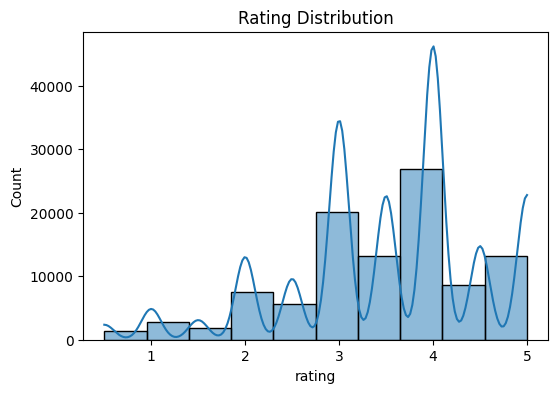

In [ ]:
# Data Visualization

plt.figure(figsize=(6,4))
sns.histplot(data['rating'], bins=10, kde=True)
plt.title("Rating Distribution")
plt.show()


### Distribution of Movie Genres

Let's visualize the frequency of different movie genres to understand the genre landscape in our dataset.

Top 10 Movie Genres:
genres
Drama        4361
Comedy       3756
Thriller     1894
Action       1828
Romance      1596
Adventure    1263
Crime        1199
Sci-Fi        980
Horror        978
Fantasy       779
Name: count, dtype: int64


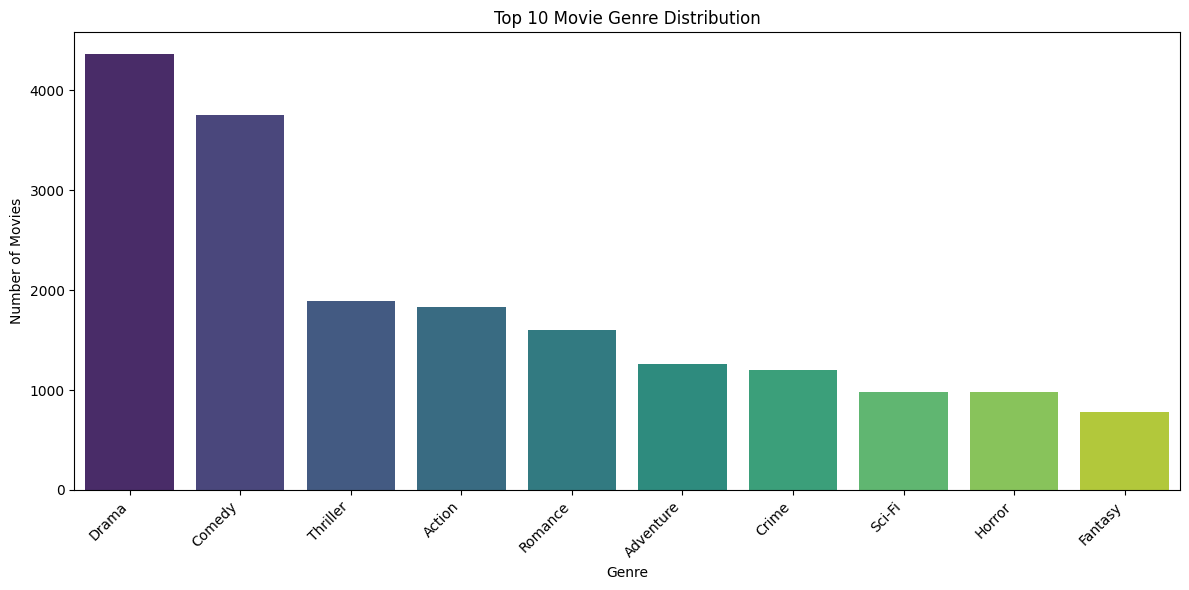

In [ ]:
# Split the 'genres' string into a list of genres for each movie
all_genres = movies['genres'].str.split('|').explode()

# Count the occurrences of each genre
genre_counts = all_genres.value_counts()

# Display the top 10 most frequent genres
print("Top 10 Movie Genres:")
print(genre_counts.head(10))

# Visualize the distribution of top genres
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.head(10).index, y=genre_counts.head(10).values, hue=genre_counts.head(10).index, palette='viridis', legend=False)
plt.title('Top 10 Movie Genre Distribution')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:

Repository:
best_clf = grid_search.best_estimator_
y_pred_tuned = best_clf.predict(X_test)

print("\nTuned Classification Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("\nTuned Classification Report:\n", classification_report(y_test, y_pred_tuned))

# Confusion Matrix for tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(5,4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues')
plt.title("Tuned Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Preprocessing
data['genres'] = data['genres'].astype('category').cat.codes

# Features & Target
X = data[['userId', 'movieId', 'genres']]
y_reg = data['rating']

# Train-Test Split (Regression)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

# Regression Model
reg = RandomForestRegressor(n_estimators=100)
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

# Regression Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("\nRegression RMSE:", rmse)




Regression RMSE: 0.9638996202589476


In [ ]:
# Classification Target
data['rating_class'] = np.where(data['rating'] >= 3.5, 1, 0)

y_cls = data['rating_class']

# Split again for classification
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=42)

# Classification Model
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)

y_pred_cls = clf.predict(X_test)

# Classification Evaluation
print("\nClassification Accuracy:", accuracy_score(y_test, y_pred_cls))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cls))




Classification Accuracy: 0.6570805236017453

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.51      0.54      7829
           1       0.71      0.75      0.73     12339

    accuracy                           0.66     20168
   macro avg       0.64      0.63      0.63     20168
weighted avg       0.65      0.66      0.65     20168



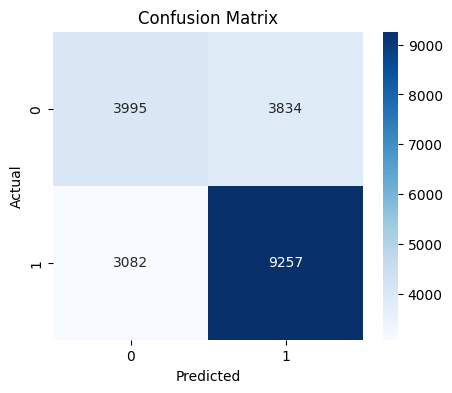

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_cls)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
movie_title_to_find = input("Enter the movie title you want to find the rating for: ")

# Find the movie and its ratings
selected_movie = data[data['title'].str.contains(movie_title_to_find, case=False, na=False)]

if not selected_movie.empty:
    # Display basic movie information and average rating
    print(f"\nMovie: {selected_movie['title'].iloc[0]}")
    print(f"Genres: {selected_movie['genres'].iloc[0]}")
    print(f"Average Rating: {selected_movie['rating'].mean():.2f}")
    print("\nAll ratings for this movie:")
    display(selected_movie[['userId', 'rating']].head())

else:
    print(f"Movie with title containing '{movie_title_to_find}' not found.")

Enter the movie title you want to find the rating for: Animation

Movie: Wallace & Gromit: The Best of Aardman Animation (1996)
Genres: 380
Average Rating: 4.09

All ratings for this movie:


,userId,rating
265,3,0.5
2415,19,4.0
2998,20,5.0
8131,57,5.0
24085,167,4.0


In [ ]:
movie_title_to_predict = input("Enter the movie title to predict its rating: ")

# Find the movie in the 'movies' DataFrame to get its movieId and genres
predicted_movie_info = movies[movies['title'].str.contains(movie_title_to_predict, case=False, na=False)]

if not predicted_movie_info.empty:
    # Take the first match if multiple movies contain the title
    target_movie_id = predicted_movie_info['movieId'].iloc[0]
    target_genres_str = predicted_movie_info['genres'].iloc[0]

    # Encode genres using the same mapping as during training
    # First, get all unique genres from the training data and create a mapping
    all_genres = data['genres'].unique()
    genre_mapping = {genre_code: genre_str for genre_str, genre_code in zip(data['genres'].astype('category').cat.categories, data['genres'].astype('category').cat.codes.unique())}



        # Create a temporary DataFrame for the target movie's genre
        temp_df = pd.DataFrame({'genres': [target_genres_str]})
        temp_df['genres'] = temp_df['genres'].astype('category')
        temp_df['genres'] = temp_df['genres'].cat.set_categories(movies['genres'].astype('category').cat.categories).cat.codes
        encoded_target_genres = temp_df['genres'].iloc[0]

        # If the genre was not seen before, cat.codes will return -1. This needs to be handled.
        if encoded_target_genres == -1:
            print(f"Warning: Genre '{target_genres_str}' not seen in training data. Cannot predict accurately.")
            # As a fallback, we could use a default genre code or skip prediction.
            # For now, we will proceed, but this prediction might be less reliable.

    except Exception as e:
        print(f"Error encoding genres: {e}")
        # Fallback if genre encoding fails, e.g., use a common genre code or skip prediction
        encoded_target_genres = 0 # Placeholder: use 0 as a default if encoding fails
        print("Using default genre code 0 for prediction.")

    # Prepare input for prediction (using a dummy userId=1)
    prediction_input = pd.DataFrame({
        'userId': [1],  # Dummy user ID for prediction
        'movieId': [target_movie_id],
        'genres': [encoded_target_genres]
    })

    # Predict with Regression Model
    predicted_rating = reg.predict(prediction_input)[0]
    print(f"\nPredicted Regression Rating for '{movie_title_to_predict}': {predicted_rating:.2f}")

    # Predict with Classification Model
    predicted_class = clf.predict(prediction_input)[0]
    predicted_class_proba = clf.predict_proba(prediction_input)[0]

    class_label = 'Good Movie' if predicted_class == 1 else 'Bad Movie'
    print(f"Predicted Classification for '{movie_title_to_predict}': {class_label} (Probability Good: {predicted_class_proba[1]:.2f}, Probability Bad: {predicted_class_proba[0]:.2f})")

else:
    print(f"Movie with title containing '{movie_title_to_predict}' not found in the dataset. Please try again or check the movie title list.")


Enter the movie title to predict its rating: comedy

Predicted Regression Rating for 'comedy': 4.25
Predicted Classification for 'comedy': Good Movie (Probability Good: 0.58, Probability Bad: 0.42)
